# Laboratorio 6 — Reconstrucción LAB2: Regresión Lineal Múltiple con Red Neuronal

Reconstrucción del **LAB2** (regresión lineal múltiple sobre `train.csv`, temperatura crítica
de superconductores) usando **PyTorch**. El LAB2 original predice `critical_temp` a partir de
81 características con descenso por el gradiente y ecuación de la normal (~R² 0.74); aquí se
reconstruye con una red neuronal que logra una inferencia más precisa.

Se utilizan:
- objeto **Dataset** y **DataLoader** para el manejo de datos,
- objeto **de costo** (`nn.MSELoss`) y **de optimización** (`optim.Adam`),
- objeto **para guardar los pesos** (`torch.save` / `state_dict`),
- **generación de métricas** (MSE, RMSE, MAE y $R^2$) sobre la partición 80/20.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from matplotlib import pyplot

torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cpu


/home/zahir/IA1/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 1. Carga y exploración del dataset

El dataset `train.csv` contiene m = 21 263 superconductores con n = 81 características
atómicas, y la columna objetivo `critical_temp` (temperatura crítica, en K).

In [2]:
df = pd.read_csv('../../LAB2/train.csv')
print(f"Registros: {df.shape[0]}, Columnas: {df.shape[1]}")

y_df = df['critical_temp'].values.astype(np.float32)
X_df = df.drop(columns=['critical_temp'])
print(f"Features n = {X_df.shape[1]}, Target (critical_temp)")

print('{:>12s}{:>12s}{:>12s}'.format('X[:,0]', 'X[:,1]', 'y'))
print('-' * 36)
for i in range(5):
    print('{:12.1f}{:12.1f}{:12.2f}'.format(X_df.values[i, 0], X_df.values[i, 1], y_df[i]))

Registros: 21263, Columnas: 82
Features n = 81, Target (critical_temp)
      X[:,0]      X[:,1]           y
------------------------------------
         4.0        88.9       29.00
         5.0        92.7       26.00
         4.0        88.9       19.00
         4.0        88.9       22.00
         4.0        88.9       23.00


## 2. Partición 80/20 y normalización

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_df.values.astype(np.float32), y_df, test_size=0.2, random_state=42
)
print(f"Entrenamiento: {X_train.shape[0]} | Prueba: {X_test.shape[0]}")

mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1.0
X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

mu_y = y_train.mean()
sigma_y = y_train.std()

y_train_n = (y_train - mu_y) / sigma_y
y_test_n = (y_test - mu_y) / sigma_y

print("Normalización: media 0 y desviación estándar 1 de las características")

Entrenamiento: 17010 | Prueba: 4253
Normalización: media 0 y desviación estándar 1 de las características


## 3. Objeto Dataset

In [4]:
class SuperconductorDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.Y[index]

In [5]:
train_set = SuperconductorDataset(X_train, y_train_n)
test_set = SuperconductorDataset(X_test, y_test_n)

batch_size = 256
train_loader = DataLoader(dataset=train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_set, batch_size=batch_size, shuffle=False)
print(f"Batches por época: {len(train_loader)}")

Batches por época: 67


## 4. Modelo (red neuronal con capas ocultas)

Se normaliza también el objetivo para acelerar la convergencia.

In [6]:
n_features = X_train.shape[1]

class RedRegresionMultiple(nn.Module):
    def __init__(self, input_size):
        super(RedRegresionMultiple, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

model = RedRegresionMultiple(n_features).to(device)
print(f"Entradas: {n_features} -> 128 -> 64 -> 1")

Entradas: 81 -> 128 -> 64 -> 1


## 5. Objetos de costo y optimización

In [7]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 6. Entrenamiento

In [8]:
num_epochs = 100
log_each = 5
J_history = []

model.train()
for epoch in range(1, num_epochs + 1):
    epoch_loss = []

    for x_b, y_b in train_loader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        pred = model(x_b)
        loss = criterion(pred, y_b)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss.append(loss.item())

    J_history.append(sum(epoch_loss) / len(epoch_loss))

    if not epoch % log_each:
        print(f"Epoca {epoch}/{num_epochs} Costo J = {J_history[-1]:.4f}")

Epoca 5/100 Costo J = 0.1743
Epoca 10/100 Costo J = 0.1494
Epoca 15/100 Costo J = 0.1396
Epoca 20/100 Costo J = 0.1270
Epoca 25/100 Costo J = 0.1236
Epoca 30/100 Costo J = 0.1177
Epoca 35/100 Costo J = 0.1088
Epoca 40/100 Costo J = 0.1045
Epoca 45/100 Costo J = 0.1016
Epoca 50/100 Costo J = 0.0963
Epoca 55/100 Costo J = 0.0909
Epoca 60/100 Costo J = 0.0944
Epoca 65/100 Costo J = 0.0882
Epoca 70/100 Costo J = 0.0861
Epoca 75/100 Costo J = 0.0841
Epoca 80/100 Costo J = 0.0830
Epoca 85/100 Costo J = 0.0806
Epoca 90/100 Costo J = 0.0816
Epoca 95/100 Costo J = 0.0820
Epoca 100/100 Costo J = 0.0807


## 7. Gráfico de costo

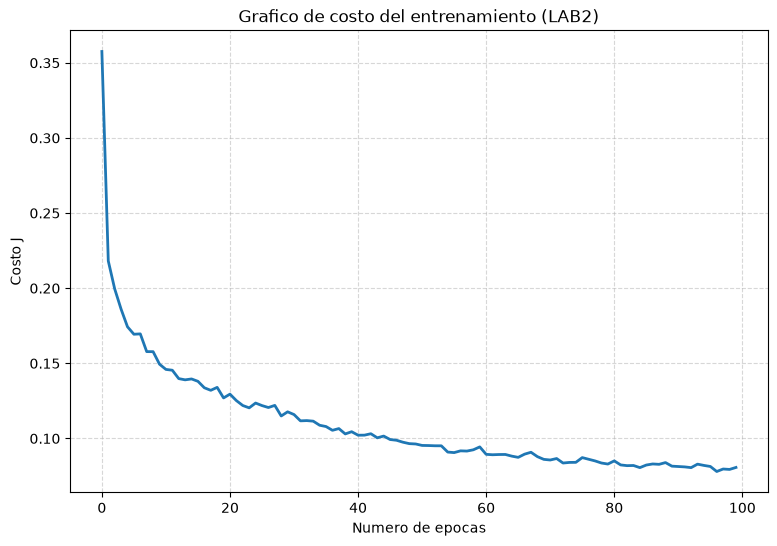

In [9]:
pyplot.figure(figsize=(9, 6))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de epocas')
pyplot.ylabel('Costo J')
pyplot.title('Grafico de costo del entrenamiento (LAB2)')
pyplot.grid(True, linestyle='--', alpha=0.5)
pyplot.savefig('costo.png')
pyplot.show()

## 8. Métricas

In [10]:
def metricas_regresion(loader, model, nombre):
    model.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            pred = model(x_b.to(device)).cpu()
            y_pred.extend((pred * sigma_y + mu_y).numpy().ravel())
            y_true.extend((y_b * sigma_y + mu_y).numpy().ravel())

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"[{nombre}] MSE = {mse:.2f} | RMSE = {rmse:.2f} | MAE = {mae:.2f} | R2 = {r2:.4f}")
    return y_true, y_pred

metricas_regresion(train_loader, model, "Entrenamiento")
y_true_test, y_pred_test = metricas_regresion(test_loader, model, "Prueba")

[Entrenamiento] MSE = 87.19 | RMSE = 9.34 | MAE = 5.83 | R2 = 0.9260
[Prueba] MSE = 110.67 | RMSE = 10.52 | MAE = 6.64 | R2 = 0.9039


## 9. Predicciones frente a los valores reales

Comparación de las primeras 200 predicciones de prueba con los valores reales.

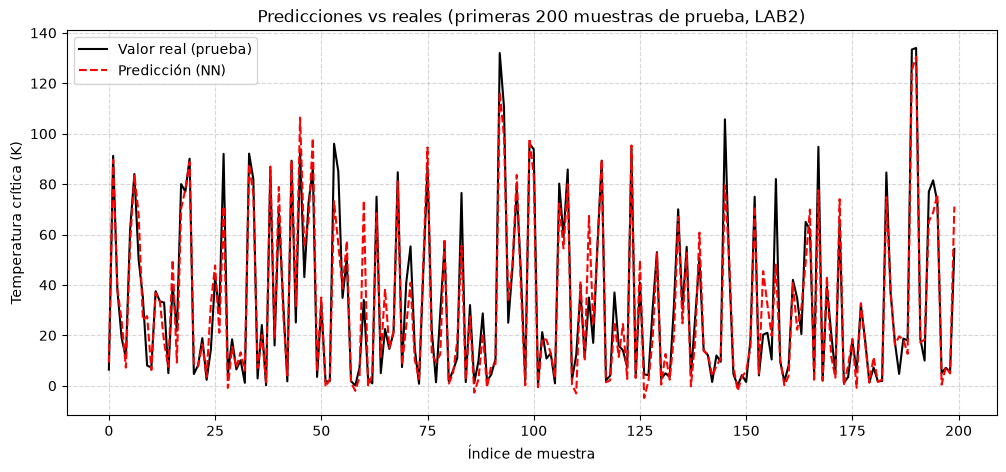

In [11]:
n_pred = 200
idx = np.arange(n_pred)

pyplot.figure(figsize=(12, 5))
pyplot.plot(idx, y_true_test[:n_pred], 'k-', lw=1.5, label='Valor real (prueba)')
pyplot.plot(idx, y_pred_test[:n_pred], 'r--', lw=1.5, label='Predicción (NN)')
pyplot.xlabel('Índice de muestra')
pyplot.ylabel('Temperatura crítica (K)')
pyplot.title('Predicciones vs reales (primeras 200 muestras de prueba, LAB2)')
pyplot.legend()
pyplot.grid(True, linestyle='--', alpha=0.5)
pyplot.savefig('predicciones.png')
pyplot.show()

## 10. Guardar los pesos del modelo

In [12]:
PATH = './checkpoint.pt'
torch.save(model.state_dict(), PATH)
print("Pesos guardados en:", PATH)

Pesos guardados en: ./checkpoint.pt


## 11. Cargar el modelo y predecir

In [13]:
model_loaded = RedRegresionMultiple(n_features).to(device)
model_loaded.load_state_dict(torch.load(PATH))
model_loaded.eval()

# Predicción del ejemplo 50 (como en el LAB2 original)
ejemplo = X_test[50:51]
ejemplo = torch.from_numpy(ejemplo).to(device)

with torch.no_grad():
    pred = (model_loaded(ejemplo).cpu() * sigma_y + mu_y).item()

print(f"Critical_temp real (ejemplo 50 de prueba): {y_test[50]:.2f}")
print(f"Critical_temp predicha: {pred:.2f}")

Critical_temp real (ejemplo 50 de prueba): 32.00
Critical_temp predicha: 35.00
